In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

df = pd.DataFrame({
    'order_id': range(1, n+1),
    'user_id': np.random.randint(1, 101, n),
    'order_date': pd.date_range('2024-01-01', periods=n, freq='H'),
    'amount': np.random.randint(10, 200, n),
    'status': np.random.choice(['completed', 'cancelled'], n, p=[0.8, 0.2])
})

df.head()

/tmp/ipykernel_1214/2551805938.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  'order_date': pd.date_range('2024-01-01', periods=n, freq='H'),


,order_id,user_id,order_date,amount,status
0,1,52,2024-01-01 00:00:00,43,completed
1,2,93,2024-01-01 01:00:00,120,completed
2,3,15,2024-01-01 02:00:00,17,completed
3,4,72,2024-01-01 03:00:00,177,completed
4,5,61,2024-01-01 04:00:00,122,completed


In [3]:
total_revenue = df['amount'].sum()

total_orders = len(df)

completed_orders = (df['status'] == 'completed').sum()

completion_rate = completed_orders / total_orders

total_revenue, total_orders, completed_orders, completion_rate

(np.int64(103107), 1000, np.int64(821), np.float64(0.821))

In [4]:
df['date'] = df['order_date'].dt.date

daily_revenue = (
    df.groupby('date')['amount']
      .sum()
      .reset_index()
)

daily_revenue.head()

,date,amount
0,2024-01-01,2548
1,2024-01-02,2253
2,2024-01-03,2496
3,2024-01-04,2491
4,2024-01-05,2496


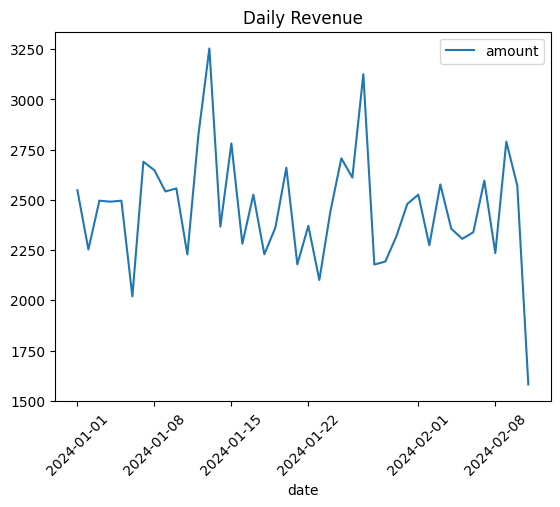

In [5]:
import matplotlib.pyplot as plt

daily_revenue.plot(x='date', y='amount')
plt.xticks(rotation=45)
plt.title('Daily Revenue')
plt.show()

### Insights

1. Revenue fluctuates across days with visible variation.
2. Dataset shows consistent order flow with majority completed (~80%).